In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.ticker as ticker

# Online Retail – Customer Segmentation using Latent Class Analysis (LCA)
## Introduction
This project applies Latent Class Analysis (LCA) to the Online Retail Dataset from the UCI Machine Learning Repository. LCA is a powerful probabilistic clustering method commonly used in survey research, but it can also model numeric and categorical behavioral data, making it well-suited for customer segmentation. Unlike traditional clustering algorithms, LCA not only identifies hidden customer groups but also reveals which variables contribute most strongly to each segment, enabling richer persona interpretation.

The Online Retail dataset contains real transactional data from a UK-based online store, covering all purchases made between 2010 and 2011. The shop offers a wide variety of products, which makes it an excellent dataset for analyzing customer purchasing patterns, shopping frequency, spending behavior, and overall engagement. Through LCA, we aim to uncover distinct customer personas and provide actionable insights that can support targeted marketing and data-driven decision-making.
### First we will start importing our dataset

In [17]:
def load_data():
    from ucimlrepo import fetch_ucirepo
    online_retail = fetch_ucirepo(id=352)
    df = online_retail.data.features.reset_index()
    df = df.rename(columns={'index':'InvoiceNo'})
    return df



In [19]:
df = load_data()

df.info()
df.head()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  int64  
 1   Description  540455 non-null  object 
 2   Quantity     541909 non-null  int64  
 3   InvoiceDate  541909 non-null  object 
 4   UnitPrice    541909 non-null  float64
 5   CustomerID   406829 non-null  float64
 6   Country      541909 non-null  object 
dtypes: float64(2), int64(2), object(3)
memory usage: 28.9+ MB


InvoiceNo           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Data Cleaning

In [4]:
## Dropping rows that CustomerID is null
df_filtered = df[df["CustomerID"].notna()].reset_index(drop=True)

## Converting CustomerID to int
df_filtered["CustomerID"] = df_filtered["CustomerID"].astype(int)

## Creating Total Price Column that will be Qty * Price
df_filtered["Total_Price"] = df_filtered["Quantity"] *  df_filtered["UnitPrice"]
## Filtering Total Price > 0
df_filtered = df_filtered[df_filtered['Total_Price'] > 0].reset_index(drop=True)

display(df_filtered)

,InvoiceNo,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Price
0,0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,15.30
1,1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34
2,2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,22.00
3,3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34
4,4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...
397879,541904,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France,10.20
397880,541905,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France,12.60
397881,541906,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France,16.60
397882,541907,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France,16.60


### [Chart] Revenue per Month

C:\Users\arthu\AppData\Local\Temp\ipykernel_18436\3861824434.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df_plot['Total_Price'].resample('M').sum()


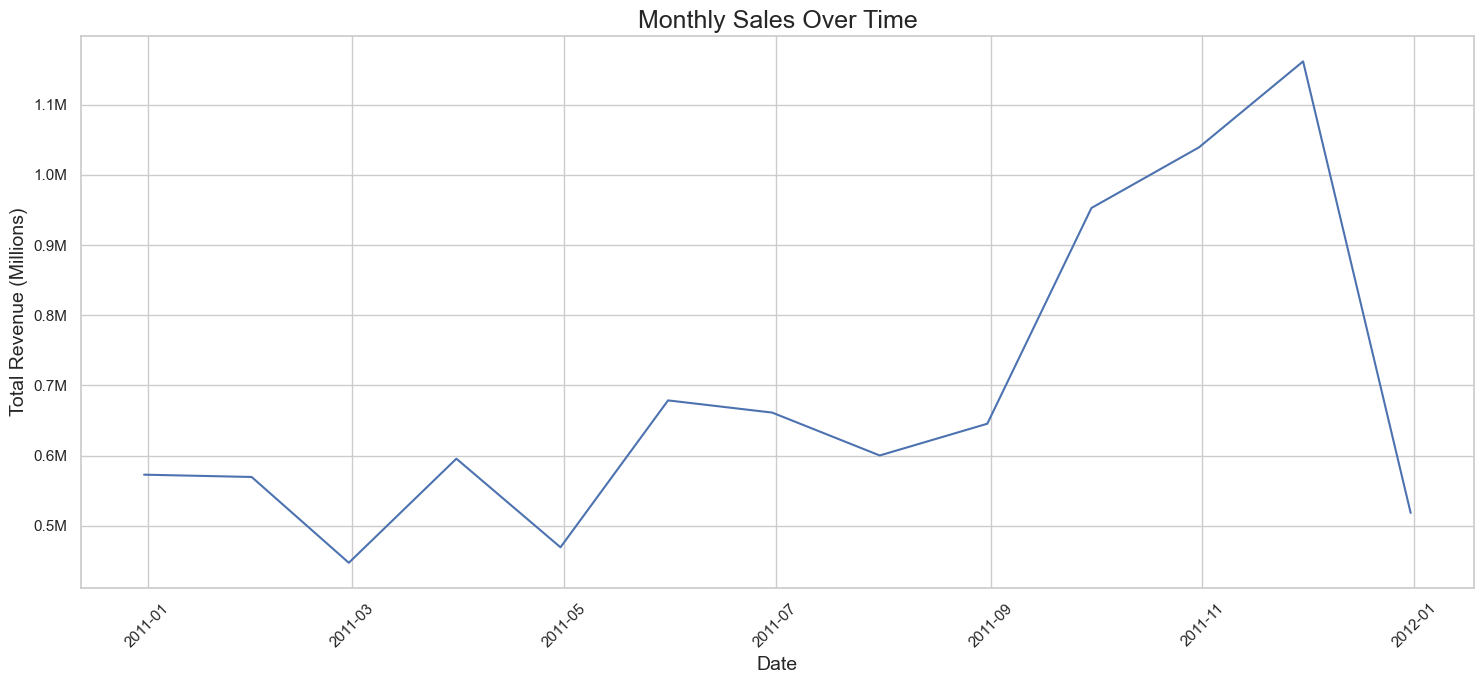

In [21]:
def plot_monthly_sales():
    # Apply a nicer style
    sns.set(style="whitegrid")

    # Create a copy to avoid modifying original df
    df_plot = df_filtered.copy()

    # Ensure the date column is datetime
    df_plot['InvoiceDate'] = pd.to_datetime(df_plot['InvoiceDate'], errors='coerce')
    df_plot = df_plot.dropna(subset=['InvoiceDate'])

    # Set date as index for resampling
    df_plot = df_plot.set_index('InvoiceDate')

    # Compute monthly sales (sum of Total_Price)
    monthly_sales = df_plot['Total_Price'].resample('M').sum()

    # Plot
    plt.figure(figsize=(15, 7))
    plt.plot(monthly_sales.index, monthly_sales.values)

    plt.title('Monthly Sales Over Time', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Total Revenue (Millions)', fontsize=14)

    # Format Y-axis in millions
    ax = plt.gca()
    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda y, pos: f'{y/1_000_000:.1f}M')
    )

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_monthly_sales()

### [Chart] Countries Revenue

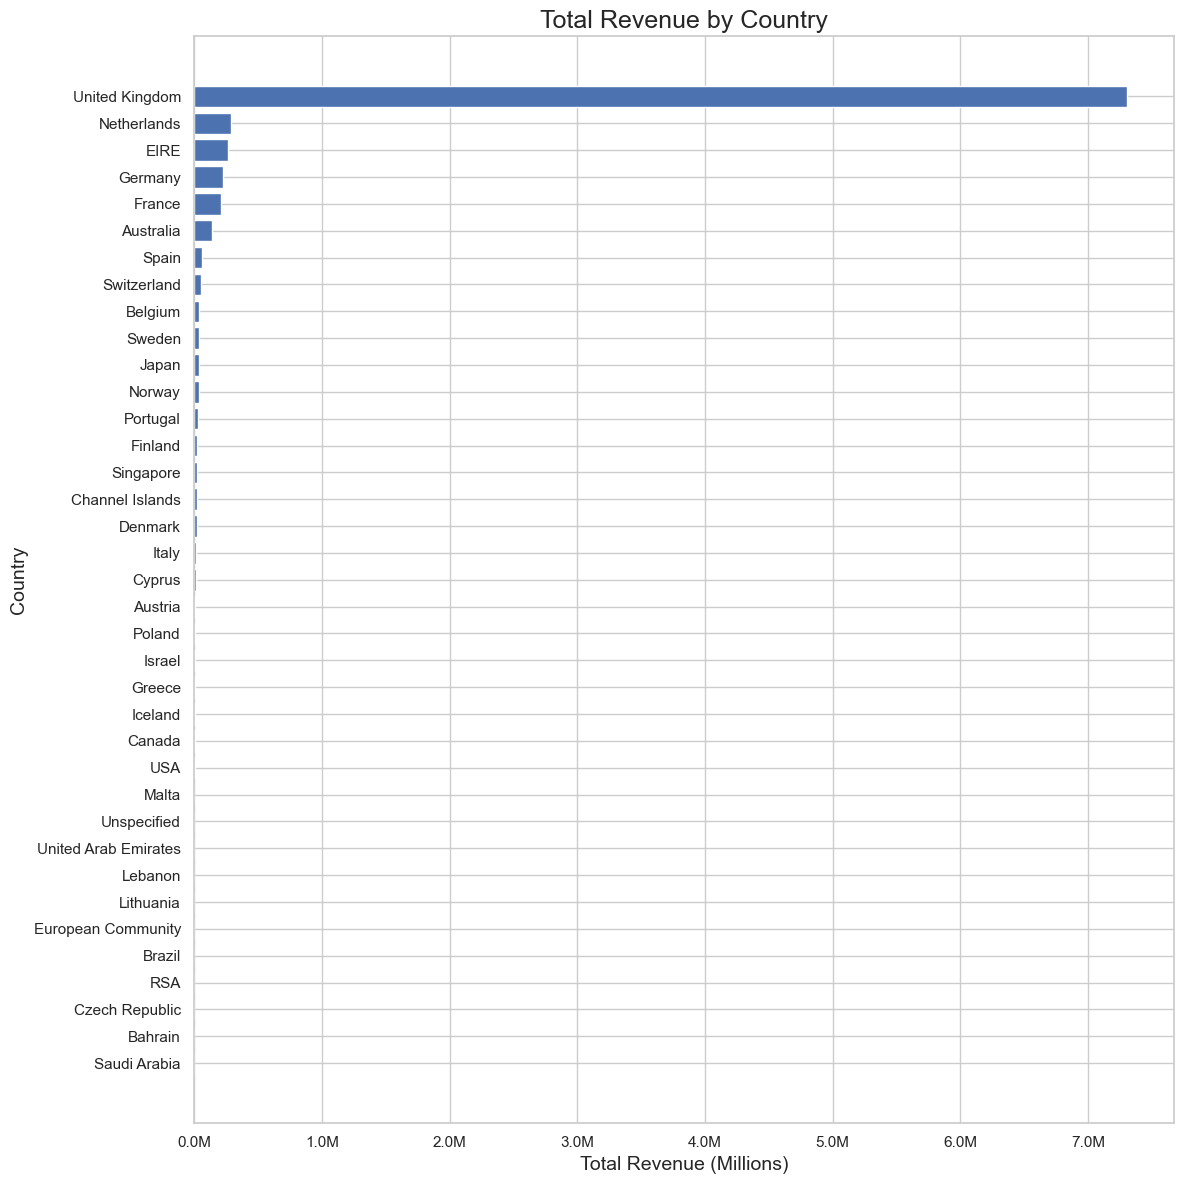

In [22]:
def plot_countries_revenue():
    # Style
    sns.set(style="whitegrid")

    # Copy df to avoid modifying original
    df_plot = df_filtered.copy()

    # Ensure column name is correct
    # (No renaming needed since your column is Total_price)

    # Group by country and sum total revenue
    country_sales = (
        df_plot.groupby('Country')['Total_Price']
            .sum()
            .sort_values(ascending=True)   # ascending=True for horizontal bars
    )

    # Plot
    plt.figure(figsize=(12, 12))
    plt.barh(country_sales.index, country_sales.values)

    plt.title("Total Revenue by Country", fontsize=18)
    plt.xlabel("Total Revenue (Millions)", fontsize=14)
    plt.ylabel("Country", fontsize=14)

    # Format axis in millions (M)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1_000_000:.1f}M'))

    plt.tight_layout()
    plt.show()

plot_countries_revenue()

### [Chart] Bottom 10 revenue Countries

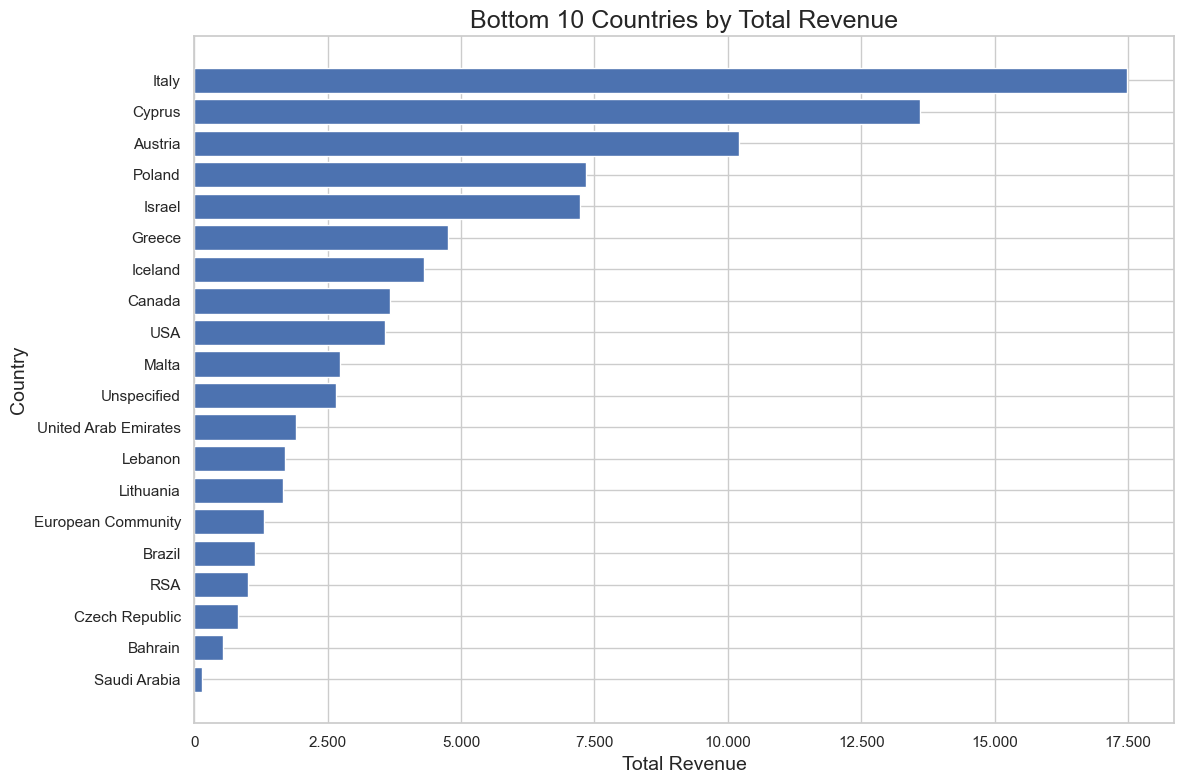

In [23]:
def plot_bot_rev_countries():
    # Style
    sns.set(style="whitegrid")

    # Copy df
    df_plot = df_filtered.copy()

    # Group by country and sum revenue
    country_sales = (
        df_plot.groupby('Country')['Total_Price']
            .sum()
            .sort_values(ascending=True)
    )

    # Select bottom 10
    bottom_10 = country_sales.head(20)

    # Formatter to use dots as thousand separator
    def dot_thousand(x, pos):
        return f"{int(x):,}".replace(",", ".")

    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(bottom_10.index, bottom_10.values)

    plt.title("Bottom 10 Countries by Total Revenue", fontsize=18)
    plt.xlabel("Total Revenue", fontsize=14)
    plt.ylabel("Country", fontsize=14)

    # Apply the formatter
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(dot_thousand))

    plt.tight_layout()
    plt.show()
    
plot_bot_rev_countries()

## Data Engineering
### Recency Frequency Monetary indicator

In [8]:
df_filtered['InvoiceDate'] = pd.to_datetime(df_filtered['InvoiceDate'])

# Getting the last transaction date to calculate recency
last_transaction_date = df_filtered['InvoiceDate'].max() + pd.Timedelta(days=1)

# Grouping data
df_rfm = df_filtered.groupby('CustomerID').agg({
    'InvoiceDate' : lambda date: (last_transaction_date - date.max()).days,
    'InvoiceNo' : 'nunique',
    'Total_Price' : 'sum'
})

# Renaming RFM column names
df_rfm.rename(columns={'InvoiceDate': 'Recency',
                       'InvoiceNo': 'Frequency',
                       'Total_Price': 'Monetary'}, inplace=True)

#Range Score for RFM
r_range_score = range(4,0,-1)
fm_range_score = range(1,5)

#Splitting Ranges in Quartiles and creating scores for each variable
df_rfm['Recency_Score'] = pd.qcut(
    df_rfm['Recency'].rank(method='first'),
    q=4,
    labels=r_range_score
)

df_rfm['Frequency_Score'] = pd.qcut(
    df_rfm['Frequency'].rank(method='first'),
    q=4,
    labels=fm_range_score
)

df_rfm['Monetary_Score'] = pd.qcut(
    df_rfm['Monetary'].rank(method='first'),
    q=4,
    labels=fm_range_score
)

#Final RFM Score
df_rfm['Final_Score'] = df_rfm['Recency_Score'].astype(int) + df_rfm['Frequency_Score'].astype(int) + df_rfm['Monetary_Score'].astype(int)  

display(df_rfm)

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,Final_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,4,6
12347,2,182,4310.00,4,4,4,12
12348,75,31,1797.24,2,2,4,8
12349,19,73,1757.55,3,3,4,10
12350,310,17,334.40,1,1,2,4
...,...,...,...,...,...,...,...
18280,278,10,180.60,1,1,1,3
18281,181,7,80.82,1,1,1,3
18282,8,12,178.05,4,1,1,6


### Joining Dataframes

In [9]:
grouped_df = df_filtered.groupby(['CustomerID', 'Country']).agg({
    'Quantity': 'sum',
    'Total_Price': 'sum',
    'InvoiceNo': 'nunique'   
})

# Renaming RFM column names
grouped_df.rename(columns={'Quantity': 'Total_products',
                       'InvoiceNo': 'Number_of_purchases',
                       'Total_Price': 'Total_value'}, inplace=True)

grouped_df = grouped_df.reset_index()

display(grouped_df)

,CustomerID,Country,Total_products,Total_value,Number_of_purchases
0,12346,United Kingdom,74215,77183.60,1
1,12347,Iceland,2458,4310.00,182
2,12348,Finland,2341,1797.24,31
3,12349,Italy,631,1757.55,73
4,12350,Norway,197,334.40,17
...,...,...,...,...,...
4341,18280,United Kingdom,45,180.60,10
4342,18281,United Kingdom,54,80.82,7
4343,18282,United Kingdom,103,178.05,12
4344,18283,United Kingdom,1397,2094.88,756


In [10]:
from sklearn.preprocessing import LabelEncoder

lca_df = pd.merge(grouped_df, df_rfm, on='CustomerID', how='inner')

## Transforming Country Names to numeric
le = LabelEncoder()
lca_df['Country_Code'] = le.fit_transform(lca_df['Country'])


display(lca_df)

,CustomerID,Country,Total_products,Total_value,Number_of_purchases,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,Final_Score,Country_Code
0,12346,United Kingdom,74215,77183.60,1,326,1,77183.60,1,1,4,6,35
1,12347,Iceland,2458,4310.00,182,2,182,4310.00,4,4,4,12,16
2,12348,Finland,2341,1797.24,31,75,31,1797.24,2,2,4,8,12
3,12349,Italy,631,1757.55,73,19,73,1757.55,3,3,4,10,18
4,12350,Norway,197,334.40,17,310,17,334.40,1,1,2,4,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4341,18280,United Kingdom,45,180.60,10,278,10,180.60,1,1,1,3,35
4342,18281,United Kingdom,54,80.82,7,181,7,80.82,1,1,1,3,35
4343,18282,United Kingdom,103,178.05,12,8,12,178.05,4,1,1,6,35
4344,18283,United Kingdom,1397,2094.88,756,4,756,2094.88,4,4,4,12,35


## Latent Class Analysis Application

In [11]:
from stepmix.stepmix import StepMix
from stepmix.utils import get_mixed_descriptor

In [12]:
continuous_variables = ['Total_value', 'Number_of_purchases', 'Total_products']
categorical_variables =  ['Country_Code', 'Recency_Score', 'Frequency_Score', 'Monetary_Score', 'Final_Score' ]

# 'CustomerID', 'Description_Code', 

# Unspecified variables are simply not included in mixed_data
mixed_data, mixed_descriptor = get_mixed_descriptor(
    dataframe=lca_df,
    continuous=continuous_variables,
    categorical=categorical_variables
)

mixed_data

,Total_value,Number_of_purchases,Total_products,Country_Code,Recency_Score,Frequency_Score,Monetary_Score,Final_Score
0,77183.60,1,74215,35,1,1,4,6
1,4310.00,182,2458,16,4,4,4,12
2,1797.24,31,2341,12,2,2,4,8
3,1757.55,73,631,18,3,3,4,10
4,334.40,17,197,24,1,1,2,4
...,...,...,...,...,...,...,...,...
4341,180.60,10,45,35,1,1,1,3
4342,80.82,7,54,35,1,1,1,3
4343,178.05,12,103,35,4,1,1,6
4344,2094.88,756,1397,35,4,4,4,12


### Model Selection

In [13]:
results = []
for k in range(2, 9):  # test 2 to 8 classes
    print(f"\nFitting model with {k} classes...")

    model = StepMix(
        n_components=k,
        measurement=mixed_descriptor,
        n_init=1,
        random_state=123,
        verbose=0
    )
    
    model.fit(mixed_data)

    ll      = model.lower_bound_               # log-likelihood
    aic     = model.aic(mixed_data)            # <== NOW PASS X
    bic     = model.bic(mixed_data)            # <== pass X
    caic    = model.caic(mixed_data)           # <== pass X
    sabic   = model.sabic(mixed_data)          # <== pass X
    entropy = model.entropy(mixed_data)        # <== pass X
    n_params = model.n_parameters               # attribute

    results.append([k, ll, aic, bic, caic, sabic, entropy])

columns = ["Classes", "LogLikelihood", "AIC", "BIC", "CAIC", "SABIC", "Entropy"]
model_comparison = pd.DataFrame(results, columns=columns)

display(model_comparison)


Fitting model with 2 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  2.69it/s, max_LL=-1.23e+5, max_avg_LL=-28.4]



Fitting model with 3 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  2.32it/s, max_LL=-1.15e+5, max_avg_LL=-26.5]



Fitting model with 4 classes...
Fitting StepMix...


...


Fitting model with 7 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:02<00:00,  2.73s/it, max_LL=-1.07e+5, max_avg_LL=-24.6]



Fitting model with 8 classes...
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:02<00:00,  2.30s/it, max_LL=-1.06e+5, max_avg_LL=-24.5]


,Classes,LogLikelihood,AIC,BIC,CAIC,SABIC,Entropy
0,2,-28.411903,247222.258294,248070.400778,248203.400778,248761.923295,76.779103
1,3,-26.542953,231111.343947,232386.746179,232586.746179,233426.629662,198.468099
2,4,-25.617132,223198.111516,224900.773496,225167.773496,226289.017947,275.528451
3,5,-25.061547,218502.970161,220632.891889,220966.891889,222369.497306,276.641191
4,6,-24.794738,216317.864639,218875.046114,219276.046114,220960.012499,395.272356
5,7,-24.600087,214759.952264,217744.393488,218212.393488,220177.720839,311.849605
6,8,-24.488953,213927.983149,217339.684120,217874.684120,220121.372439,332.244261


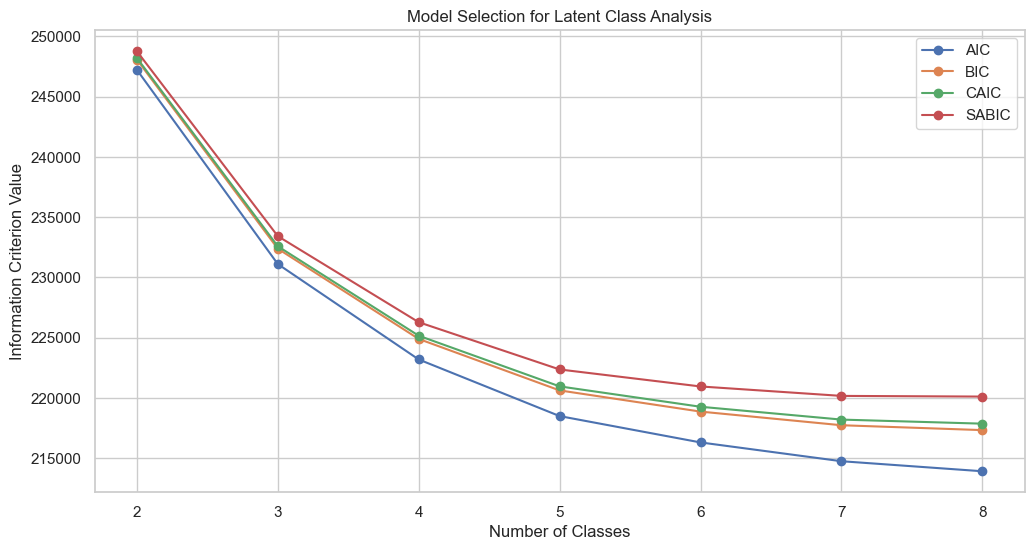

In [24]:
def plot_model_selection_variables():
    plt.figure(figsize=(12, 6))
    plt.plot(model_comparison["Classes"], model_comparison["AIC"], marker='o', label="AIC")
    plt.plot(model_comparison["Classes"], model_comparison["BIC"], marker='o', label="BIC")
    plt.plot(model_comparison["Classes"], model_comparison["CAIC"], marker='o', label="CAIC")
    plt.plot(model_comparison["Classes"], model_comparison["SABIC"], marker='o', label="SABIC")

    plt.title("Model Selection for Latent Class Analysis")
    plt.xlabel("Number of Classes")
    plt.ylabel("Information Criterion Value")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_model_selection_variables()

### Conclusion

To determine the optimal number of latent customer segments, Latent Class Analysis (LCA) models were fitted with 2 to 8 classes.
Each model was evaluated using standard information criteria:

* AIC (Akaike Information Criterion)

* BIC (Bayesian Information Criterion)

* CAIC (Consistent Akaike Information Criterion)

* SABIC (Sample-Size Adjusted BIC)

* Entropy (class separation quality)

* Log-likelihood

Lower values of AIC/BIC/CAIC/SABIC indicate better model fit with appropriate complexity.
Higher entropy indicates clearer, more separable clusters.

While the 8-class model had the lowest BIC, the improvement after 6 classes was marginal, indicating diminishing returns.
BIC and SABIC consistently decreased as more classes were added, with the lowest values around the 6–8 class region.

Entropy increased as more classes were added, peaking strongly at the 6-class model.
After 6 classes, entropy dropped again, indicating decreasing separation quality.

So, 6-class model model provides the clearest, most stable cluster structure while maintaining excellent statistical fit, making it the best choice for customer segmentation in the Online Retail dataset.

In [15]:
model = StepMix(
    n_components=6,
    measurement=mixed_descriptor,
    n_init=1,
    random_state=123,
    verbose=3
)

model.fit(mixed_data)

# Class predictions
lca_df['mixed_pred'] = model.predict(mixed_data)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:02<00:00,  2.11s/it, max_LL=-1.08e+5, max_avg_LL=-24.8]


In [16]:
# Get class predictions
lca_df["Class"] = model.predict(mixed_data)

# Show summary statistics by class
class_summary = lca_df.groupby("Class").agg({
    "Number_of_purchases": "mean",
    "Total_products": "mean",
    "Total_value": "mean",
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
})

display(class_summary)

# Class distribution
lca_df["Class"].value_counts()

,Number_of_purchases,Total_products,Total_value,Recency,Frequency,Monetary
Class,,,,,,
0,277.903967,3078.887265,5214.243507,23.384134,278.386221,5223.560376
1,851.026316,24594.907895,43100.499079,19.460526,851.026316,43100.499079
2,127.134276,1097.276796,1897.177598,45.742049,127.734982,1913.821320
3,8.235704,93.598326,161.555914,160.779637,8.235704,161.555914
4,27.376238,214.276403,378.552081,131.576733,27.413366,379.950563
5,52.386969,558.154985,940.575361,74.586377,52.508391,944.573890


Class
4    1212
5    1013
2     849
3     717
0     479
1      76
Name: count, dtype: int64

## Class Interpretation

The 6-class latent class model reveals six distinct customer profiles based on purchasing behavior, value contribution, and recency of activity.  
Below, each class is described using its observed characteristics.

---

### **Class 1 — Ultra High-Value “Wholesale-Like” Buyers**
**(76 customers — 1.7%)**

- Extremely high purchase frequency: **~851 purchases**
- Massive product volume: **~24,595 items**
- Very high monetary value: **~43,100 total spend**
- Recent purchasers: **~19 days recency**
- Tiny segment but disproportionately important for revenue
- Likely **B2B or bulk buyers**

**Business implication:**  
Prioritize retention: personalized deals, dedicated account management, and long-term loyalty programs.

---

### **Class 0 — High-Value Active Customers**
**(479 customers — 11%)**

- High frequency: **~278 purchases**
- Large product volume: **~3,079 items**
- High monetary spend: **~5,214**
- Low recency (**~23 days**) → still very active
- Below Class 1 in scale but still highly valuable

**Business implication:**  
Maintain engagement with exclusive promotions, upsells, and VIP benefits.

---

### **Class 2 — Moderate Buyers with Low Recency (Still Active)**
**(849 customers — 19%)**

- Medium frequency: **~127 purchases**
- Medium product quantity: **~1,097 items**
- Medium spend: **~1,897**
- Recency **~46 days** → moderately active
- Stable mid-tier segment

**Business implication:**  
Ideal for cross-selling opportunities and early reactivation campaigns.

---

### **Class 5 — Low-to-Moderate Buyers, Mid Recency**
**(1,013 customers — 23%)**

- ~52 purchases  
- ~558 products  
- ~940 monetary value  
- Recency **~75 days** → becoming inactive
- Still profitable but beginning to disengage

**Business implication:**  
Target with re-engagement: discounts, personalized recommendations, abandoned cart prompts.

---

### **Class 4 — Low Buyers, High Recency (Churning Customers)**
**(1,212 customers — 28% — largest group)**

- ~27 purchases  
- ~214 products  
- ~379 spend  
- Very high recency **~132 days**
- Decreasing engagement, high risk of churn

**Business implication:**  
Reactivation needed: win-back campaigns, special offers, re-targeting ads.

---

### **Class 3 — Very Low-Value, Highly Inactive Customers**
**(717 customers — 16%)**

- Only ~8 purchases  
- Very low product quantity (**~94**)  
- Very low spend (**~162**)  
- Extremely high recency (**~161 days**)  
- Almost completely disengaged

**Business implication:**  
Low ROI in reactivation. Use automated, low-cost marketing (email drips, periodic reminders).

---
